### Figure 1 
subplot of 
- (a) hydrophone acoustic signal to obtain critical shear stress
- (b) example of Aich (2014) hysteresis calculations
- (c) hydrograph specific transport metrics example 

Note: Hex codes for viridis colors: 
- #440154 (Dark Purple / Violet)
- #3b528b (Deep Blue)
- #21918c (Teal)
- #5ec962 (Light Green)
- #fde725 (Yellow)

In [1]:
import os
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import seaborn as sns


# import data 
shear_stress = pd.read_csv('../../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
dmax = pd.read_csv('st2_hydrophone_dmax.csv', parse_dates=['Time'], index_col='Time')
sonde_downstream = pd.read_csv('../../data/sonde_data/sonde_down_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
sonde_downstream = sonde_downstream.groupby(level=0).mean(numeric_only=True)


shear_stress = shear_stress.resample('1min').interpolate()
dmax = dmax.join(shear_stress, how="left")
sonde_downstream = sonde_downstream.join(shear_stress['shear_stress'], how="left")
# modify the specific dates 
dmax_c = dmax.loc['2022-08-03 12:00:00':'2022-08-04 17:00:00']
dmax = dmax.loc['2022-08-03 13:00:00':'2022-08-03 21:00:00']
sonde_downstream = sonde_downstream.loc['2021-07-23 13:19:00':'2021-07-28 11:15:00']


In [2]:
sonde_downstream

,Turbidity FNU,fDOM RFU,shear_stress
DateTime,,,
2021-07-23 13:19:00,6.756,17.832,66.549392
2021-07-23 13:24:00,7.278,18.886,66.936485
2021-07-23 13:29:00,6.730,19.530,67.323578
2021-07-23 13:34:00,5.592,20.112,67.297530
2021-07-23 13:39:00,4.784,20.516,67.168197
...,...,...,...
2021-07-28 10:15:00,2.642,17.894,66.145617
2021-07-28 10:30:00,2.636,17.922,66.020200
2021-07-28 10:45:00,2.628,17.914,66.020200


### (a) hydrophone acoustic signal to obtain critical shear stress

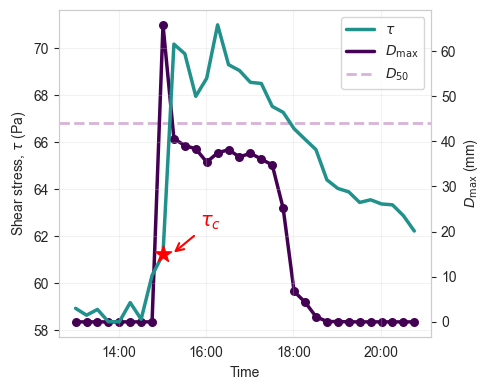

In [3]:
teal = '#21918c'
purple = "#440154"

D50 = 44  # mm
sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(5, 4))

# shear stress line
ax1.plot(dmax.index, dmax["shear_stress"], color=teal, lw=2.5, label=r"$\tau$", zorder=5)
ax1.set_ylabel(r"Shear stress, $\tau$ (Pa)")
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
# Dmax line
ax2.plot(dmax.index, dmax["Dmax (mm)"], color=purple, lw=2.5, label=r"$D_{\max}$", zorder=5)
ax2.scatter(dmax.index, dmax["Dmax (mm)"], color=purple, s=30, zorder=5)
ax2.set_ylabel(r"$D_{\max}$ (mm)")
ax2.tick_params(axis="y")
# horizontal line showing D50
ax2.axhline(D50, color="purple", ls="--", lw=2, label=r"$D_{50}$", alpha=0.3)

# find the index of the first Dmax that exceeds D50
idx = dmax[dmax["Dmax (mm)"] >= D50].index[0]
tau_c = dmax.loc[idx, "shear_stress"]
ax1.scatter(idx, tau_c, color="red", s=150, zorder=20, marker="*")
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

# annotate tau_c
ax1.annotate(r"$\tau_c$", xy=(idx+pd.Timedelta(hours=0.2), tau_c), xytext=(20,20), textcoords="offset points", color="red",
    fontsize=14, arrowprops=dict(arrowstyle="->", color="red", lw=1.5), zorder=100)
xmin = dmax.index.min()
xmax = idx
# horizontal line showing tauc
#ax1.hlines(tau_c, xmin=dmax.index[0], xmax=idx, color="red", linestyle="--", linewidth=2, zorder=10)
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.25)
ax2.grid(False)

# combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

### (b) example of Aich (2014) hysteresis calculations

In [4]:
def normalize_data(df, tau_col, constituent_col):
    pair = df[[tau_col, constituent_col]].copy()
    pair[tau_col] = pd.to_numeric(pair[tau_col], errors="coerce")
    pair[constituent_col] = pd.to_numeric(pair[constituent_col], errors="coerce")
    pair = pair.dropna(subset=[tau_col, constituent_col]).sort_index()
    pair = pair.reset_index(drop=True)

    if pair.empty:
        return None

    tau_max = pair[tau_col].max()
    cn_max = pair[constituent_col].max()

    if pd.isna(tau_max) or pd.isna(cn_max) or tau_max == 0 or cn_max == 0:
        return None

    pair["tau_n"] = pair[tau_col] / tau_max
    pair["cn"] = pair[constituent_col] / cn_max
    return pair

def split_hydrograph(norm_df):
    if norm_df.empty:
        return None, None, None

    peak_pos = norm_df["tau_n"].to_numpy().argmax()
    rise = norm_df.iloc[:peak_pos + 1][["tau_n", "cn"]]
    fall = norm_df.iloc[peak_pos + 1:][["tau_n", "cn"]]

    return rise, fall, peak_pos

def reference_line(norm_df, peak_pos):
    peak_row = norm_df.iloc[peak_pos]
    last_row = norm_df.iloc[-1]

    x1 = peak_row["tau_n"]
    y1 = peak_row["cn"]
    x2 = last_row["tau_n"]
    y2 = last_row["cn"]

    A = y1 - y2
    B = x2 - x1
    C = x1 * y2 - x2 * y1
    return A, B, C

def distance_from_line(df_xy, A, B, C):
    return (A * df_xy["tau_n"] + B * df_xy["cn"] + C) / np.sqrt(A**2 + B**2)

def projection_to_line(x0, y0, A, B, C):
    d = (A * x0 + B * y0 + C) / (A**2 + B**2)
    x_proj = x0 - A * d
    y_proj = y0 - B * d
    return x_proj, y_proj

def calculate_aich_HI(df, tau_col, constituent_col, storm_name):
    norm_df = normalize_data(df, tau_col, constituent_col)

    if norm_df is None or len(norm_df) < 3:
        print(f"Not enough paired data to calculate AICH HI for storm {storm_name}")
        return None

    rise, fall, peak_pos = split_hydrograph(norm_df)

    if rise is None or fall is None or rise.empty or fall.empty:
        print(f"Not enough data points to calculate AICH HI for storm {storm_name}")
        return None

    A, B, C = reference_line(norm_df, peak_pos)

    rise_dist = -distance_from_line(rise, A, B, C)
    fall_dist = distance_from_line(fall, A, B, C)

    if rise_dist.empty or fall_dist.empty:
        print(f"Not enough data points to calculate AICH HI for storm {storm_name}")
        return None

    rise_idx = rise_dist.abs().to_numpy().argmax()
    fall_idx = fall_dist.abs().to_numpy().argmax()

    Drise = rise_dist.iloc[rise_idx]
    Dfall = fall_dist.iloc[fall_idx]
    HI = Drise + Dfall

    results = {
        "HI": HI,
        "Drise": Drise,
        "Dfall": Dfall,
        "storm_name": storm_name,
        "peak tau": norm_df.iloc[peak_pos]["tau_n"],
        "peak constituent": norm_df.iloc[peak_pos]["cn"],
        "rise": rise,
        "fall": fall,
        "A": A,
        "B": B,
        "C": C,
        "Drise_point": (rise.iloc[rise_idx]["tau_n"], rise.iloc[rise_idx]["cn"]),
        "Dfall_point": (fall.iloc[fall_idx]["tau_n"], fall.iloc[fall_idx]["cn"]),
        "norm_df": norm_df,
    }
    return results

In [5]:
def plot_aich_hysteresis(results, xlabel=r"Normalized Shear Stress ($\tau_n$)", ylabel="Normalized Constituent ($C_n$)", save=False, show=True):
    norm_df = results["norm_df"]
    rise = results["rise"]
    fall = results["fall"]

    A = results["A"]
    B = results["B"]
    C = results["C"]

    Drise = results["Drise"]
    Dfall = results["Dfall"]
    HI = results["HI"]
    xr, yr = results["Drise_point"]
    xf, yf = results["Dfall_point"]

    xr_proj, yr_proj = projection_to_line(xr, yr, A, B, C)
    xf_proj, yf_proj = projection_to_line(xf, yf, A, B, C)

    xmin = min(norm_df["tau_n"].min(), xr_proj, xf_proj) - 0.05
    xmax = max(norm_df["tau_n"].max(), xr_proj, xf_proj) + 0.05
    xline = np.linspace(xmin, xmax, 200)
    yline = -(A * xline + C) / B

    rise_color = "#24918D"       # teal
    fall_color = "#440154"       # dark purple
    reference_color = "gray"

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(norm_df["tau_n"], norm_df["cn"], color="0.35", linewidth=2, alpha=0.65, zorder=1)
    ax.plot(rise["tau_n"], rise["cn"], color=rise_color, linewidth=2.5, zorder=3)
    ax.scatter(rise["tau_n"], rise["cn"], color=rise_color, s=55, label="Rising limb", zorder=4)
    ax.plot(fall["tau_n"], fall["cn"], color=fall_color, linewidth=2.5, zorder=3)
    ax.scatter(fall["tau_n"], fall["cn"], color=fall_color, s=55, label="Falling limb", zorder=4)
    # reference line
    ax.plot(xline, yline, linestyle="--", color=reference_color, linewidth=2.5, label="Reference line", zorder=2)

    # Drise measurement
    ax.plot([xr, xr_proj], [yr, yr_proj], linestyle="--", color=rise_color, linewidth=2.5, zorder=5)
    ax.scatter([xr, xr_proj], [yr, yr_proj], color=rise_color, s=70, zorder=6)
    # midpoint of Drise segment
    xr_mid = (xr + xr_proj) / 2
    yr_mid = (yr + yr_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{rise}}$",
        xy=(xr_mid, yr_mid),
        xytext=(20, 12),
        textcoords="offset points",
        color=rise_color,
        fontsize=12,
        fontweight="bold",
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )
    # Dfall measurement
    ax.plot([xf, xf_proj], [yf, yf_proj], linestyle="--", color=fall_color, linewidth=2.5, zorder=5)
    ax.scatter([xf, xf_proj], [yf, yf_proj], color=fall_color, s=70, zorder=6)
    # Midpoint of Dfall segment
    xf_mid = (xf + xf_proj) / 2
    yf_mid = (yf + yf_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{fall}}$",
        xy=(xf_mid, yf_mid),
        xytext=(10, -12),
        textcoords="offset points",
        color=fall_color,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )

    # Axis limits with equal scaling
    geom_x = np.r_[norm_df["tau_n"].to_numpy(), xr, xr_proj, xf, xf_proj]
    geom_y = np.r_[norm_df["cn"].to_numpy(), yr, yr_proj, yf, yf_proj]

    x_min, x_max = geom_x.min(), geom_x.max()
    y_min, y_max = geom_y.min(), geom_y.max()

    x_span = x_max - x_min
    y_span = y_max - y_min
    span = max(x_span, y_span)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)

    pad = 0.08 * span
    ax.set_xlim(
        x_mid - span / 2 - pad,
        x_mid + span / 2 + pad
    )
    ax.set_ylim(
        y_mid - span / 2 - pad,
        y_mid + span / 2 + pad
    )
    ax.set_aspect("equal", adjustable="box")

    # formatting
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    # Put HI in a small box rather than the title
    summary_text = (
        rf"$D_{{\mathrm{{rise}}}}={Drise:.2f}$" "\n"
        rf"$D_{{\mathrm{{fall}}}}={Dfall:.2f}$" "\n"
        rf"$HI={HI:.2f}$"
    )

    ax.text(
        0.70,
        0.97,
        summary_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        linespacing=1.4,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="none",
            edgecolor="1",
            alpha=0.9
        ),
        zorder=10
    )

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, loc="lower right")
    fig.tight_layout()
    plt.show()

def plot_aich_hysteresis_switch(results, xlabel=r"Normalized Shear Stress ($\tau_n$)", ylabel="Normalized Constituent ($C_n$)", save=False, show=True):
    norm_df = results["norm_df"]
    fall = results["rise"]
    rise = results["fall"]

    A = results["A"]
    B = results["B"]
    C = results["C"]

    Dfall = results["Drise"]*-1
    Drise = results["Dfall"]*-1
    HI = results["HI"]*-1
    xf, yf = results["Drise_point"]
    xr, yr = results["Dfall_point"]

    xr_proj, yr_proj = projection_to_line(xr, yr, A, B, C)
    xf_proj, yf_proj = projection_to_line(xf, yf, A, B, C)

    xmin = min(norm_df["tau_n"].min(), xr_proj, xf_proj) - 0.05
    xmax = max(norm_df["tau_n"].max(), xr_proj, xf_proj) + 0.05
    xline = np.linspace(xmin, xmax, 200)
    yline = -(A * xline + C) / B

    fall_color = "#5ec962"             # "#24918D"     the commented one is teal  
    rise_color = "#440154"       # dark purple
    reference_color = "gray"

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(norm_df["tau_n"], norm_df["cn"], color="0.35", linewidth=2, alpha=0.65, zorder=1)
    ax.plot(rise["tau_n"], rise["cn"], color=rise_color, linewidth=2.5, zorder=3)
    ax.scatter(rise["tau_n"], rise["cn"], color=rise_color, s=55, label="Rising limb", zorder=4)
    ax.plot(fall["tau_n"], fall["cn"], color=fall_color, linewidth=2.5, zorder=3)
    ax.scatter(fall["tau_n"], fall["cn"], color=fall_color, s=55, label="Falling limb", zorder=4)
    # reference line
    ax.plot(xline, yline, linestyle="--", color=reference_color, linewidth=2.5, label="Reference line", zorder=2)

    # Drise measurement
    ax.plot([xr, xr_proj], [yr, yr_proj], linestyle="--", color=rise_color, linewidth=2.5, zorder=5)
    ax.scatter([xr, xr_proj], [yr, yr_proj], color=rise_color, s=70, zorder=6)
    # midpoint of Drise segment
    xr_mid = (xr + xr_proj) / 2
    yr_mid = (yr + yr_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{rise}}$",
        xy=(xr_mid, yr_mid),
        xytext=(40, -15),
        textcoords="offset points",
        color=rise_color,
        fontsize=12,
        fontweight="bold",
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )
    # Dfall measurement
    ax.plot([xf, xf_proj], [yf, yf_proj], linestyle="--", color=fall_color, linewidth=2.5, zorder=5)
    ax.scatter([xf, xf_proj], [yf, yf_proj], color=fall_color, s=70, zorder=6)
    # Midpoint of Dfall segment
    xf_mid = (xf + xf_proj) / 2
    yf_mid = (yf + yf_proj) / 2

    ax.annotate(
        r"$D_{\mathrm{fall}}$",
        xy=(xf_mid, yf_mid),
        xytext=(0, 10),
        textcoords="offset points",
        color=fall_color,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=8
    )

    # Axis limits with equal scaling
    geom_x = np.r_[norm_df["tau_n"].to_numpy(), xr, xr_proj, xf, xf_proj]
    geom_y = np.r_[norm_df["cn"].to_numpy(), yr, yr_proj, yf, yf_proj]

    x_min, x_max = geom_x.min(), geom_x.max()
    y_min, y_max = geom_y.min(), geom_y.max()

    x_span = x_max - x_min
    y_span = y_max - y_min
    span = max(x_span, y_span)

    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)

    pad = 0.08 * span
    ax.set_xlim(
        x_mid - span / 2 - pad,
        x_mid + span / 2 + pad
    )
    ax.set_ylim(
        y_mid - span / 2 - pad,
        y_mid + span / 2 + pad
    )
    ax.set_aspect("equal", adjustable="box")

    # formatting
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    # Put HI in a small box rather than the title
    summary_text = (
        rf"$D_{{\mathrm{{rise}}}}={Drise:.2f}$" "\n"
        rf"$D_{{\mathrm{{fall}}}}={Dfall:.2f}$" "\n"
        rf"$HI={HI:.2f}$"
    )

    ax.text(
        0.70,
        0.97,
        summary_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        linespacing=1.4,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="none",
            edgecolor="1",
            alpha=0.9
        ),
        zorder=10
    )

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, loc="lower right")
    fig.tight_layout()
    plt.show()

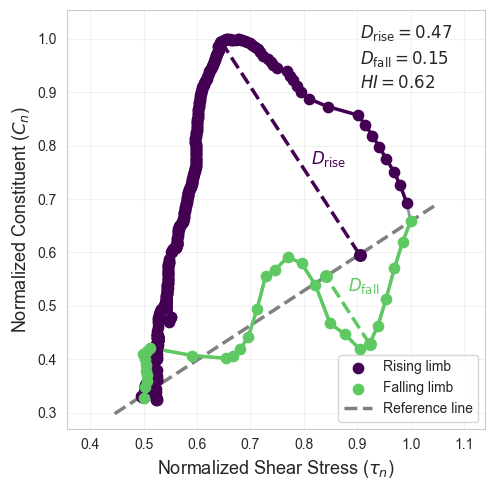

In [6]:
results_fdom = calculate_aich_HI(sonde_downstream, tau_col="shear_stress", constituent_col="fDOM RFU", storm_name="example storm")
plot_aich_hysteresis_switch(results=results_fdom)

### (c) hydrograph specific transport metric

In [7]:
def plot_tau_timing(df, tau_c, tau_col="shear_stress", figsize=(5, 4)):
    data = df[[tau_col]].copy()
    data[tau_col] = pd.to_numeric(data[tau_col], errors="coerce")
    data = data.dropna().sort_index()

    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)
    tau = data[tau_col]

    peak_time = tau.idxmax()
    peak_tau = tau.loc[peak_time]

    rising = tau.loc[:peak_time]
    falling = tau.loc[peak_time:]
    rising_candidates = rising[rising <= tau_c]
    falling_candidates = falling[falling <= tau_c]

    rising_tau_c_time = rising_candidates.index[-1]
    falling_tau_c_time = falling_candidates.index[0]
    rising_tau_value = tau.loc[rising_tau_c_time]
    falling_tau_value = tau.loc[falling_tau_c_time]

    # calculate elapsed times
    t_rise = peak_time - rising_tau_c_time
    t_fall = falling_tau_c_time - peak_time

    t_rise_hours = t_rise.total_seconds() / 3600
    t_fall_hours = t_fall.total_seconds() / 3600

    # colors
    hydrograph_color = "#21918c"
    rising_color = "#440154"
    falling_color = "#5ec962"
    threshold_color = "red"
    guide_color = "0.55"

    # PLOT!!!!!!
    fig, ax = plt.subplots(figsize=figsize)
    # hydrograph
    ax.plot(data.index, tau, color=hydrograph_color, linewidth=2.8, label=r"$\tau$", zorder=2)
    # rising portion from tau_c to peak
    rise_segment = tau.loc[rising_tau_c_time:peak_time].copy()
    rise_segment.iloc[0] = tau_c  # force the first highlighted value to begin exactly at tau_c
    ax.plot(rise_segment.index, rise_segment, color=rising_color, linewidth=3, label="Rising limb", zorder=4)
    # falling portion from peak to tau_c
    fall_segment = tau.loc[peak_time:falling_tau_c_time].copy()
    fall_segment.iloc[-1] = tau_c  # force the last highlighted value to end exactly at tau_c
    ax.plot(fall_segment.index, fall_segment, color=falling_color, linewidth=3, label="Falling interval", zorder=4)
    # tau_c horizontal threshold
    ax.hlines(y=tau_c, xmin=rising_tau_c_time, xmax=falling_tau_c_time, color=threshold_color, linestyle=":", linewidth=2.5, zorder=3)
    # vertical guides
    for time in [rising_tau_c_time, peak_time, falling_tau_c_time]:
        ax.axvline(time, color=guide_color, linestyle=('--'), linewidth=2, zorder=1, alpha=0.75)
    # important points
    ax.scatter(rising_tau_c_time, tau_c, marker="*", color=threshold_color, edgecolor=threshold_color, s=220, zorder=8)
    ax.scatter(peak_time, peak_tau, color=guide_color, edgecolor="white", linewidth=0.8, s=75, zorder=8)
    ax.scatter(falling_tau_c_time, falling_tau_value, marker="x", color=falling_color, linewidth=2.5, s=100, zorder=8)
    
    # tau_c label
    ax.annotate(
        r"$\tau_c$",
        xy=(rising_tau_c_time, tau_c),
        xytext=(-34, 20),
        textcoords="offset points",
        color=threshold_color,
        fontsize=15,
        arrowprops=dict(
            arrowstyle="->",
            color=threshold_color,
            linewidth=1.8,
            shrinkB=5,
        ),
        zorder=10
    )
    # peak label
    ax.annotate(
        "Peak",
        xy=(peak_time, peak_tau),
        xytext=(35, -15),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=13,
        color=guide_color,
        arrowprops=dict(
            arrowstyle="->",
            color=guide_color,
            linewidth=1.8,
            shrinkB=5,
        ),
        zorder=10
    )

    # duration arrows
    tau_min = tau.min()
    tau_range = peak_tau - tau_min
    arrow_y = tau_min + 0.10 * tau_range

    # rising-time arrow
    ax.annotate("", xy=(peak_time, arrow_y), xytext=(rising_tau_c_time, arrow_y),
        arrowprops=dict(arrowstyle="<->", color=rising_color, linewidth=2.3), zorder=7)
    ax.text(rising_tau_c_time + (peak_time - rising_tau_c_time) / 2, arrow_y - 0.03 * tau_range,
    r"$t_{\mathrm{rise}}$", color=rising_color, fontsize=13, ha="center", va="top")

    # falling-time arrow
    ax.annotate("", xy=(falling_tau_c_time, arrow_y), xytext=(peak_time, arrow_y),
        arrowprops=dict(arrowstyle="<->", color=falling_color, linewidth=2.3), zorder=7)
    ax.text(peak_time + (falling_tau_c_time - peak_time) / 2, arrow_y - 0.03 * tau_range,
    r"$t_{\mathrm{fall}}$", color=falling_color, fontsize=13, ha="center", va="top")
    
    # rising and falling time labels
    box_style = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", linewidth=0.7, alpha=0.9)
    timing_text = (rf"$t_{{\mathrm{{rise}}}} = {t_rise_hours:.2f}\ \mathrm{{h}}$"
        "\n" rf"$t_{{\mathrm{{fall}}}} = {t_fall_hours:.2f}\ \mathrm{{h}}$")
    ax.text(0.97, 0.95, timing_text, transform=ax.transAxes,
        ha="right", va="top", fontsize=12, color="black", linespacing=1.4, bbox=box_style, zorder=20)

    # formatting
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Shear stress, $\tau$ (Pa)")

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    ax.grid(True, alpha=0.25)
    # ax.legend(frameon=True, loc="best")

    # add lower space for duration arrows
    ax.set_ylim(tau_min - 0.12 * tau_range, peak_tau + 0.10 * tau_range)
    fig.tight_layout()
    plt.show()

    return {
        "rising_tau_c_time": rising_tau_c_time,
        "peak_time": peak_time,
        "falling_tau_c_time": falling_tau_c_time,
        "t_rise": t_rise,
        "t_fall": t_fall,
        "t_rise_hours": t_rise_hours,
        "t_fall_hours": t_fall_hours
    }

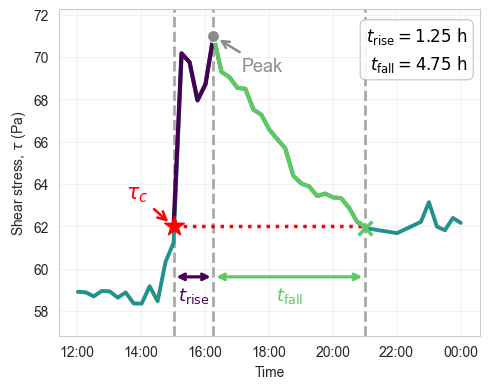

In [8]:
timing_results = plot_tau_timing(
    df=dmax_c,
    tau_c=62,
    tau_col="shear_stress"
)

### Subplot of all three plots

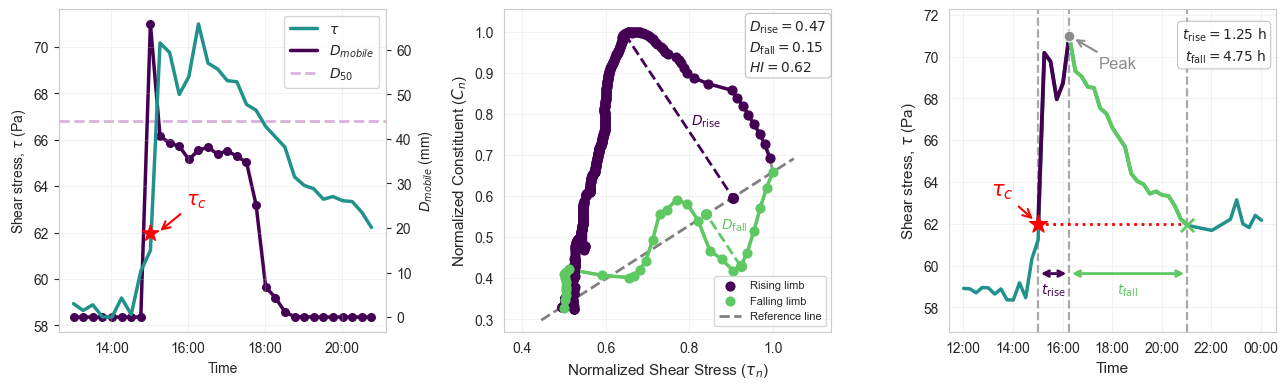

In [10]:
teal = '#21918c'
purple = "#440154"
green = "#5ec962"

def _project_to_line(x0, y0, a, b, c):
    denom = a * a + b * b
    return (
        x0 - a * (a * x0 + b * y0 + c) / denom,
        y0 - b * (a * x0 + b * y0 + c) / denom,
    )
def _draw_hysteresis_panel(ax, results, switch=False):
    norm_df = results["norm_df"]
    if switch:
        rise = results["fall"]
        fall = results["rise"]
        Drise = results["Dfall"] * -1
        Dfall = results["Drise"] * -1
        HI = results["HI"] * -1
        xf, yf = results["Drise_point"]
        xr, yr = results["Dfall_point"]
        rise_color = "#440154"
        fall_color = "#5ec962"
    else:
        rise = results["rise"]
        fall = results["fall"]
        Drise = results["Drise"]
        Dfall = results["Dfall"]
        HI = results["HI"]
        xr, yr = results["Drise_point"]
        xf, yf = results["Dfall_point"]
        rise_color = "#24918D"
        fall_color = "#440154"

    A = results["A"]
    B = results["B"]
    C = results["C"]

    xr_proj, yr_proj = _project_to_line(xr, yr, A, B, C)
    xf_proj, yf_proj = _project_to_line(xf, yf, A, B, C)

    xmin = min(norm_df["tau_n"].min(), xr_proj, xf_proj) - 0.05
    xmax = max(norm_df["tau_n"].max(), xr_proj, xf_proj) + 0.05
    xline = np.linspace(xmin, xmax, 200)
    yline = -(A * xline + C) / B

    ax.plot(norm_df["tau_n"], norm_df["cn"], color="0.35", linewidth=2, alpha=0.65, zorder=1)
    ax.plot(rise["tau_n"], rise["cn"], color=rise_color, linewidth=2.5, zorder=3)
    ax.scatter(rise["tau_n"], rise["cn"], color=rise_color, s=40, label="Rising limb", zorder=4)
    ax.plot(fall["tau_n"], fall["cn"], color=fall_color, linewidth=2.5, zorder=3)
    ax.scatter(fall["tau_n"], fall["cn"], color=fall_color, s=40, label="Falling limb", zorder=4)
    ax.plot(xline, yline, linestyle="--", color="gray", linewidth=2.0, label="Reference line", zorder=2)

    ax.plot([xr, xr_proj], [yr, yr_proj], linestyle="--", color=rise_color, linewidth=2.0, zorder=5)
    ax.scatter([xr, xr_proj], [yr, yr_proj], color=rise_color, s=50, zorder=6)
    ax.plot([xf, xf_proj], [yf, yf_proj], linestyle="--", color=fall_color, linewidth=2.0, zorder=5)
    ax.scatter([xf, xf_proj], [yf, yf_proj], color=fall_color, s=50, zorder=6)

    xr_mid = (xr + xr_proj) / 2
    yr_mid = (yr + yr_proj) / 2
    xf_mid = (xf + xf_proj) / 2
    yf_mid = (yf + yf_proj) / 2

    # D rise text
    ax.annotate(
        r"$D_{\mathrm{rise}}$",
        xy=(xr_mid, yr_mid),
        xytext=(30, -10),
        textcoords="offset points",
        color=rise_color,
        fontsize=10,
        fontweight="bold",
        ha="right",
        va="bottom",
        zorder=8,
    )
    # D fall text
    ax.annotate(
        r"$D_{\mathrm{fall}}$",
        xy=(xf_mid, yf_mid),
        xytext=(-2, 5),
        textcoords="offset points",
        color=fall_color,
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="bottom",
        zorder=8,
    )

    geom_x = np.r_[norm_df["tau_n"].to_numpy(), xr, xr_proj, xf, xf_proj]
    geom_y = np.r_[norm_df["cn"].to_numpy(), yr, yr_proj, yf, yf_proj]
    x_min, x_max = geom_x.min(), geom_x.max()
    y_min, y_max = geom_y.min(), geom_y.max()
    span = max(x_max - x_min, y_max - y_min)
    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)
    pad = 0.08 * span

    ax.set_xlim(x_mid - span / 2 - pad, x_mid + span / 2 + pad)
    ax.set_ylim(y_mid - span / 2 - pad, y_mid + span / 2 + pad)
    #ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"Normalized Shear Stress ($\tau_n$)", fontsize=11)
    ax.set_ylabel("Normalized Constituent ($C_n$)", fontsize=11)

    summary_text = (
        rf"$D_{{\mathrm{{rise}}}}={Drise:.2f}$" "\n"
        rf"$D_{{\mathrm{{fall}}}}={Dfall:.2f}$" "\n"
        rf"$HI={HI:.2f}$"
    )
    ax.text(
        0.75,
        0.97,
        summary_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.30", facecolor="white", edgecolor="0.7", linewidth=0.7, alpha=0.9),
        zorder=10,
    )
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, loc="lower right", fontsize=8)

def _draw_tau_timing_panel(ax, df, tau_c, tau_col="shear_stress"):
    data = df[[tau_col]].copy()
    data[tau_col] = pd.to_numeric(data[tau_col], errors="coerce")
    data = data.dropna().sort_index()

    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)

    tau = data[tau_col]
    peak_time = tau.idxmax()
    peak_tau = tau.loc[peak_time]

    rising = tau.loc[:peak_time]
    falling = tau.loc[peak_time:]
    rising_candidates = rising[rising <= tau_c]
    falling_candidates = falling[falling <= tau_c]

    rising_tau_c_time = rising_candidates.index[-1]
    falling_tau_c_time = falling_candidates.index[0]
    falling_tau_value = tau.loc[falling_tau_c_time]

    t_rise_hours = (peak_time - rising_tau_c_time).total_seconds() / 3600
    t_fall_hours = (falling_tau_c_time - peak_time).total_seconds() / 3600

    hydrograph_color = "#21918c"
    rising_color = "#440154"
    falling_color = "#5ec962"
    threshold_color = "red"
    guide_color = "0.55"

    ax.plot(data.index, tau, color=hydrograph_color, linewidth=2.5, label=r"$\tau$", zorder=2)

    rise_segment = tau.loc[rising_tau_c_time:peak_time].copy()
    rise_segment.iloc[0] = tau_c
    ax.plot(rise_segment.index, rise_segment, color=rising_color, linewidth=2.8, label="Rising limb", zorder=4)

    fall_segment = tau.loc[peak_time:falling_tau_c_time].copy()
    fall_segment.iloc[-1] = tau_c
    ax.plot(fall_segment.index, fall_segment, color=falling_color, linewidth=2.8, label="Falling interval", zorder=4)

    ax.hlines(y=tau_c, xmin=rising_tau_c_time, xmax=falling_tau_c_time, color=threshold_color, linestyle=":", linewidth=2.0, zorder=3)
    for time in [rising_tau_c_time, peak_time, falling_tau_c_time]:
        ax.axvline(time, color=guide_color, linestyle="--", linewidth=1.6, zorder=1, alpha=0.75)

    ax.scatter(rising_tau_c_time, tau_c, marker="*", color=threshold_color, edgecolor=threshold_color, s=180, zorder=8)
    ax.scatter(peak_time, peak_tau, color=guide_color, edgecolor="white", linewidth=0.8, s=60, zorder=8)
    ax.scatter(falling_tau_c_time, falling_tau_value, marker="x", color=falling_color, linewidth=2.0, s=90, zorder=8)

    # tau_c label
    ax.annotate(
        r"$\tau_c$",
        xy=(rising_tau_c_time, tau_c),
        xytext=(-34, 20),
        textcoords="offset points",
        color=threshold_color,
        fontsize=15,
        arrowprops=dict(
            arrowstyle="->",
            color=threshold_color,
            linewidth=1.5,
            shrinkB=5,
        ),
        zorder=10
    )
    # peak label
    ax.annotate(
        "Peak",
        xy=(peak_time, peak_tau),
        xytext=(35, -15),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=12,
        color=guide_color,
        arrowprops=dict(
            arrowstyle="->",
            color=guide_color,
            linewidth=1.5,
            shrinkB=5,
        ),
        zorder=10
    )

    tau_min = tau.min()
    tau_range = peak_tau - tau_min
    arrow_y = tau_min + 0.10 * tau_range

    ax.annotate("", xy=(peak_time, arrow_y), xytext=(rising_tau_c_time, arrow_y), arrowprops=dict(arrowstyle="<->", color=rising_color, linewidth=2.0), zorder=7)
    ax.annotate("", xy=(falling_tau_c_time, arrow_y), xytext=(peak_time, arrow_y), arrowprops=dict(arrowstyle="<->", color=falling_color, linewidth=2.0), zorder=7)
    ax.text(rising_tau_c_time + (peak_time - rising_tau_c_time) / 2, arrow_y - 0.03 * tau_range, r"$t_{\mathrm{rise}}$", color=rising_color, fontsize=10, ha="center", va="top")
    ax.text(peak_time + (falling_tau_c_time - peak_time) / 2, arrow_y - 0.03 * tau_range, r"$t_{\mathrm{fall}}$", color=falling_color, fontsize=10, ha="center", va="top")

    timing_text = (
        rf"$t_{{\mathrm{{rise}}}} = {t_rise_hours:.2f}\ \mathrm{{h}}$" "\n"
        rf"$t_{{\mathrm{{fall}}}} = {t_fall_hours:.2f}\ \mathrm{{h}}$"
    )
    ax.text(
        0.97,
        0.95,
        timing_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.30", facecolor="white", edgecolor="0.7", linewidth=0.7, alpha=0.9),
        zorder=20,
    )

    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel(r"Shear stress, $\tau$ (Pa)", fontsize=11)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_ylim(tau_min - 0.12 * tau_range, peak_tau + 0.10 * tau_range)
    ax.grid(True, alpha=0.25)

###### PLOT ########
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ax1 = axes[0]
# shear stress line
ax1.plot(dmax.index, dmax["shear_stress"], color=teal, lw=2.5, label=r"$\tau$", zorder=5)
ax1.set_ylabel(r"Shear stress, $\tau$ (Pa)")
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis="y")
ax2 = ax1.twinx()
# Dmax line
ax2.plot(dmax.index, dmax["Dmax (mm)"], color=purple, lw=2.5, label=r"$D_{mobile}$", zorder=5)
ax2.scatter(dmax.index, dmax["Dmax (mm)"], color=purple, s=30, zorder=5)
ax2.set_ylabel(r"$D_{mobile}$ (mm)")
ax2.tick_params(axis="y")
# horizontal line showing D50
ax2.axhline(D50, color="purple", ls="--", lw=2, label=r"$D_{50}$", alpha=0.3)

# find the index of the first Dmax that exceeds D50
idx = dmax[dmax["Dmax (mm)"] >= D50].index[0]
tau_c = 62
ax1.scatter(idx, tau_c, color="red", s=150, zorder=20, marker="*")
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)
# annotate tau_c
ax1.annotate(r"$\tau_c$", xy=(idx + pd.Timedelta(hours=0.2), tau_c), xytext=(20, 20), textcoords="offset points", color="red",
    fontsize=14, arrowprops=dict(arrowstyle="->", color="red", lw=1.5), zorder=100)
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.25)
ax2.grid(False)
# combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=True, loc="upper right")

_draw_hysteresis_panel(axes[1], results_fdom, switch=True)
_draw_tau_timing_panel(axes[2], dmax_c, tau_c=62, tau_col="shear_stress")

fig.tight_layout()
fig.savefig("figure1.png", dpi=1000, bbox_inches="tight")
plt.show()